# 03 - Exploratory Data Analysis

Visualize trends in the cleaned match data: matches per season, wins by team, toss patterns, venues, cities, player-of-the-match frequency, and win percentage by team.

Charts are saved to `../images/`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
IMAGES_DIR = '../images'
os.makedirs(IMAGES_DIR, exist_ok=True)

matches = pd.read_csv('../data/processed/matches_cleaned.csv', parse_dates=['date'])
matches.shape

(1212, 11)

## Matches played per season

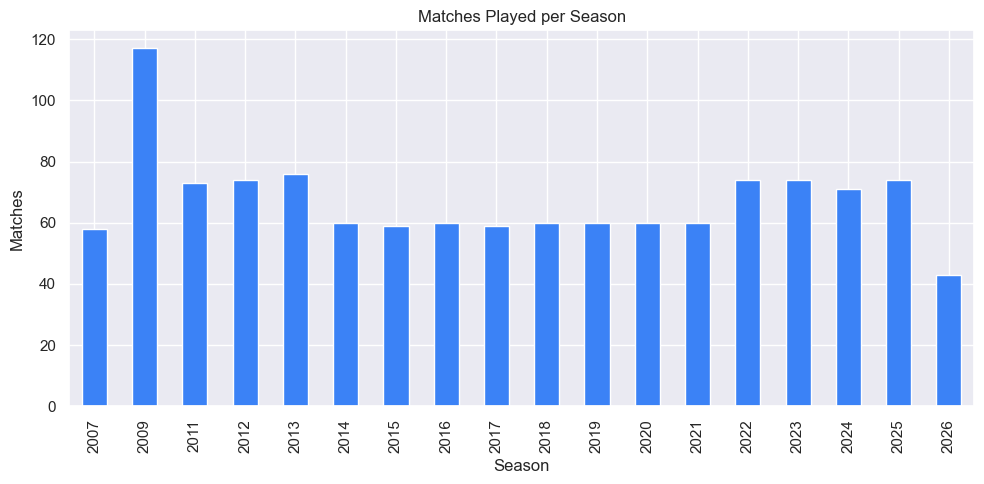

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
matches['season'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3b82f6')
ax.set_title('Matches Played per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Matches')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/matches_per_season.png', dpi=150)
plt.show()

## Matches won by each team

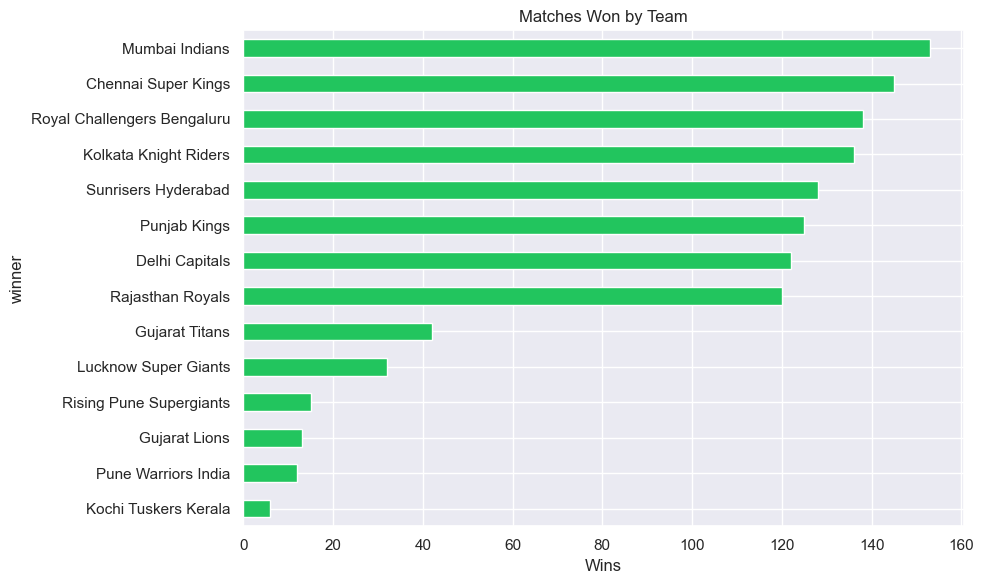

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
matches['winner'].value_counts().plot(kind='barh', ax=ax, color='#22c55e')
ax.invert_yaxis()
ax.set_title('Matches Won by Team')
ax.set_xlabel('Wins')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/matches_won_by_team.png', dpi=150)
plt.show()

## Toss winner distribution

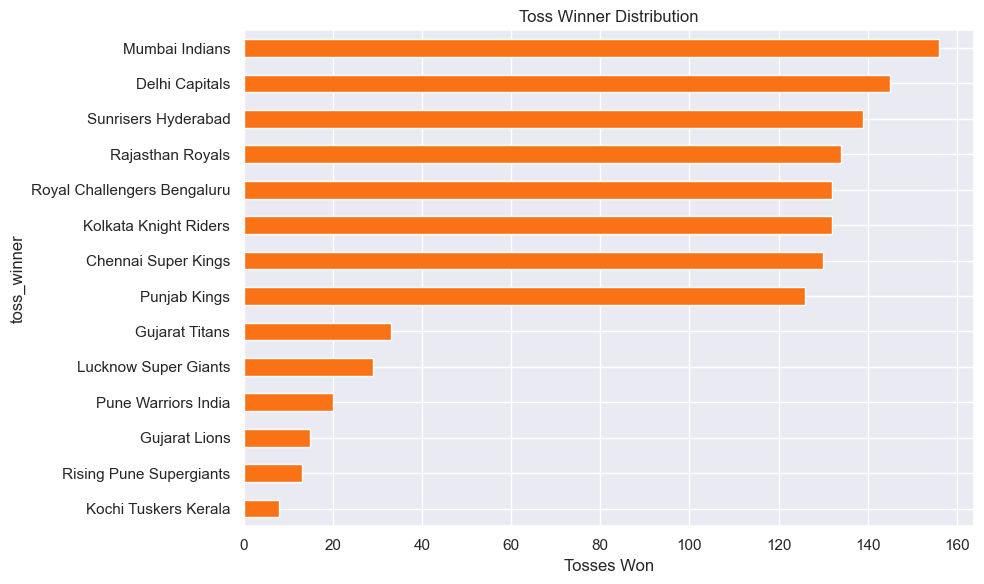

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
matches['toss_winner'].value_counts().plot(kind='barh', ax=ax, color='#f97316')
ax.invert_yaxis()
ax.set_title('Toss Winner Distribution')
ax.set_xlabel('Tosses Won')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/toss_winner_distribution.png', dpi=150)
plt.show()

## Toss decision distribution

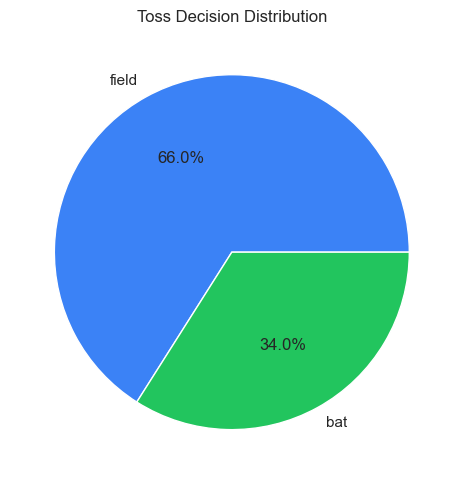

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
matches['toss_decision'].value_counts().plot(
    kind='pie', ax=ax, autopct='%1.1f%%', colors=['#3b82f6', '#22c55e'], ylabel=''
)
ax.set_title('Toss Decision Distribution')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/toss_decision_distribution.png', dpi=150)
plt.show()

## Venue-wise matches

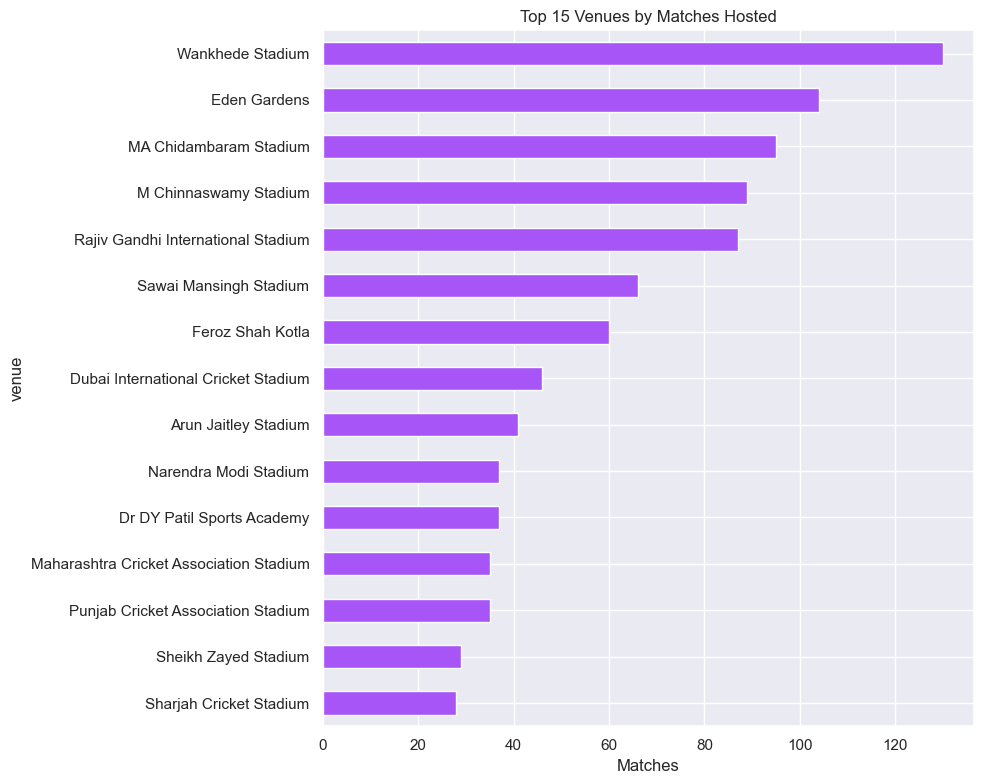

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
matches['venue'].value_counts().head(15).plot(kind='barh', ax=ax, color='#a855f7')
ax.invert_yaxis()
ax.set_title('Top 15 Venues by Matches Hosted')
ax.set_xlabel('Matches')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/venue_wise_matches.png', dpi=150)
plt.show()

## City-wise matches

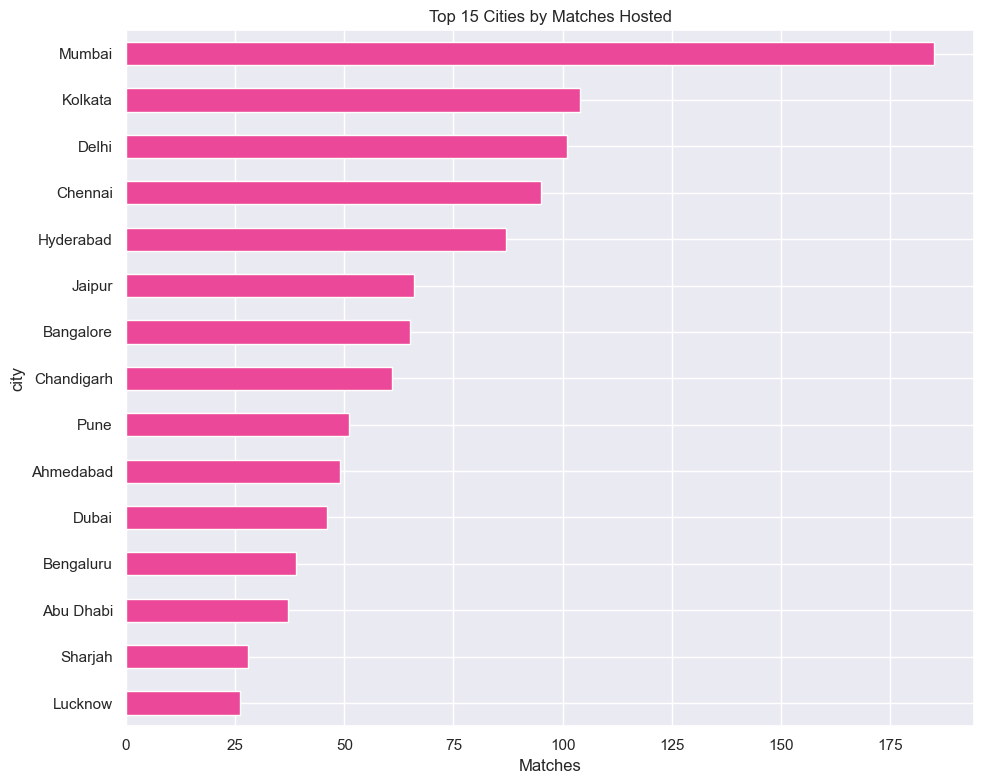

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
matches['city'].value_counts().head(15).plot(kind='barh', ax=ax, color='#ec4899')
ax.invert_yaxis()
ax.set_title('Top 15 Cities by Matches Hosted')
ax.set_xlabel('Matches')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/city_wise_matches.png', dpi=150)
plt.show()

## Player of the Match frequency

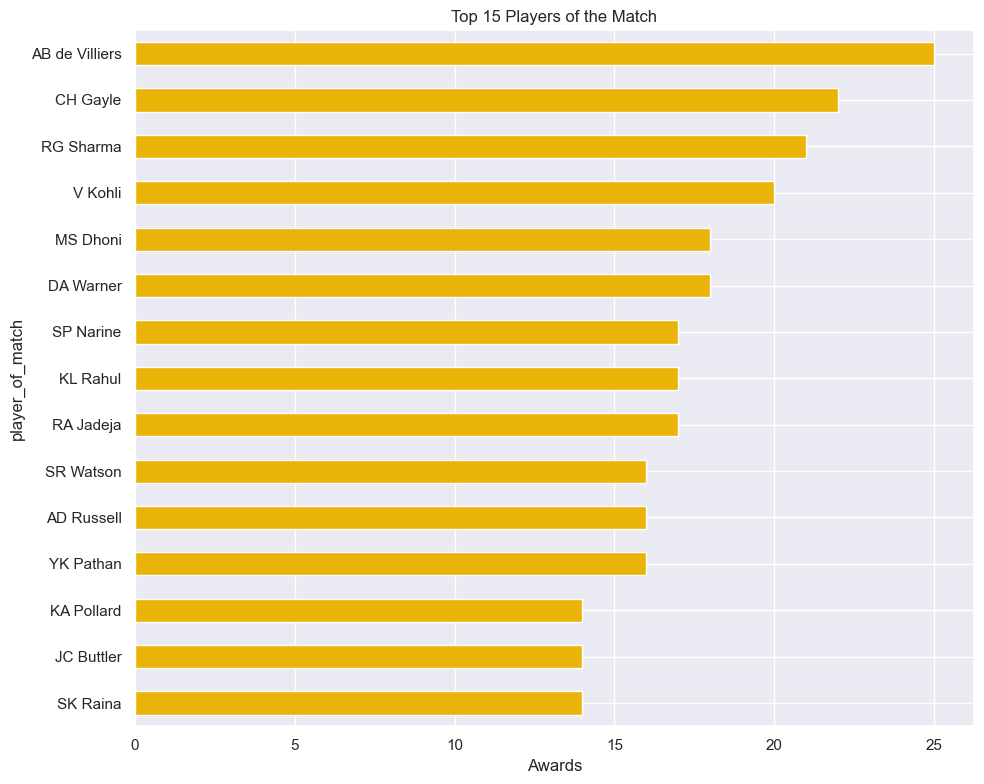

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
matches['player_of_match'].value_counts().head(15).plot(kind='barh', ax=ax, color='#eab308')
ax.invert_yaxis()
ax.set_title('Top 15 Players of the Match')
ax.set_xlabel('Awards')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/player_of_match_frequency.png', dpi=150)
plt.show()

## Winning percentage by team

Wins as a percentage of matches played (team1 + team2 appearances).

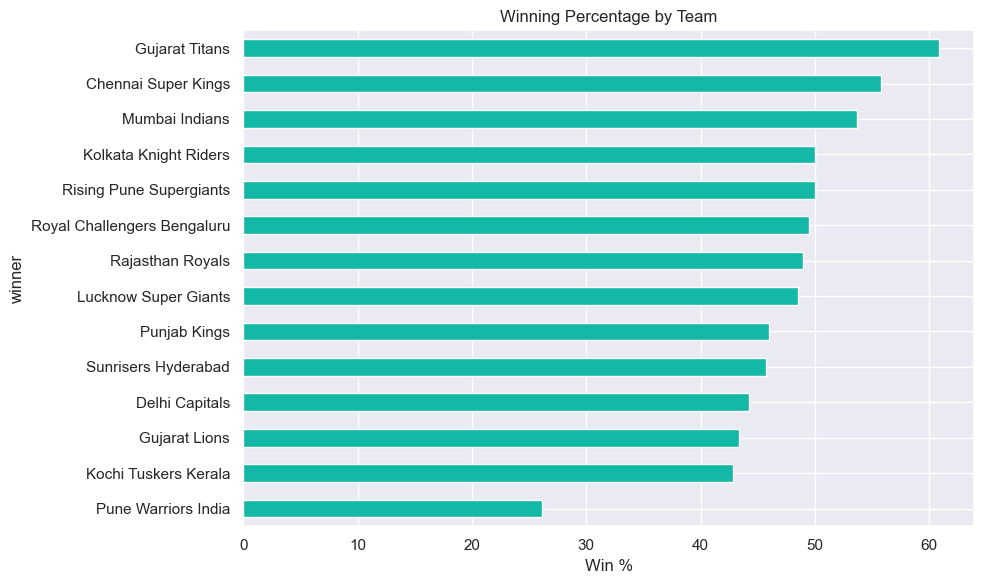

In [9]:
played = pd.concat([matches['team1'], matches['team2']]).value_counts()
won = matches['winner'].value_counts()
win_pct = (won / played * 100).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
win_pct.plot(kind='barh', ax=ax, color='#14b8a6')
ax.invert_yaxis()
ax.set_title('Winning Percentage by Team')
ax.set_xlabel('Win %')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/win_percentage_by_team.png', dpi=150)
plt.show()